# LSTM Vocal Confidence Scoring (Phase 2)
Trains a 2-layer LSTM on **direct MFCC + delta + pitch audio features** (no spectrograms) extracted from Mini LibriSpeech.
Saves checkpoints and feature arrays to Google Drive. Pushes final model to Hugging Face.

**Architecture:** Input (200 frames × 42 features) → LSTM(128) → LSTM(64) → Dense(32) → confidence score 0–1

**Why no spectrograms:** Direct numerical features feed natively into LSTMs as time-series sequences.
Every dimension carries meaning (MFCCs, delta, pitch, energy, ZCR). No image-conversion overhead,
lower data requirements, fully interpretable features, and native temporal modelling.

In [1]:
!pip install librosa soundfile datasets tensorflow huggingface_hub matplotlib seaborn scikit-learn --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import numpy as np
import librosa
import soundfile as sf
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# ── Directories ──────────────────────────────────────────────────────────────
CHECKPOINT_DIR   = '/content/drive/MyDrive/PersonaPath/checkpoints'
FEATURE_DIR      = '/content/drive/MyDrive/PersonaPath/lstm_features'
VISUALIZATION_DIR= '/content/drive/MyDrive/PersonaPath/visualizations'
DATA_DIR         = '/content/librispeech'

for d in [CHECKPOINT_DIR, FEATURE_DIR, VISUALIZATION_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready.')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

Directories ready.
GPU available: True


In [7]:
from huggingface_hub import notebook_login
print('Log in to Hugging Face to push your model later:')
notebook_login()

Log in to Hugging Face to push your model later:


## 1. Download Mini LibriSpeech
Mini LibriSpeech (OpenSLR-31) contains ~1.5 GB of read English speech with transcript alignments.
We use it to build a proxy confidence dataset: clips with high word-rate and low silence = confident;
clips with low word-rate and high silence = nervous/hesitant.

In [8]:
import urllib.request, tarfile

LIBRI_URL  = 'https://www.openslr.org/resources/31/train-clean-5.tar.gz'
TARBALL    = '/content/train-clean-5.tar.gz'
LIBRI_ROOT = '/content/librispeech/LibriSpeech'

if not os.path.exists(LIBRI_ROOT):
    print('Downloading Mini LibriSpeech (~1.5 GB)...')
    urllib.request.urlretrieve(LIBRI_URL, TARBALL)
    print('Extracting...')
    with tarfile.open(TARBALL) as t:
        t.extractall('/content/librispeech')
    os.remove(TARBALL)
    print('Done.')
else:
    print('LibriSpeech already extracted.')

# Collect all .flac files
audio_files = []
for root, _, files in os.walk(LIBRI_ROOT):
    for f in files:
        if f.endswith('.flac'):
            audio_files.append(os.path.join(root, f))

print(f'Found {len(audio_files):,} audio clips.')

Extracting...


/tmp/ipykernel_11288/3607561406.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/content/librispeech')


Done.
Found 1,519 audio clips.


In [ ]:
import shutil
import os

SOURCE_DIR = '/content/librispeech'
DEST_DIR   = '/content/drive/MyDrive/PersonaPath/data/librispeech'

# Copy only if not already saved
if not os.path.exists(DEST_DIR):
    print("Saving dataset to Drive...")
    shutil.copytree(SOURCE_DIR, DEST_DIR)
    print("Saved to Drive.")
else:
    print("Dataset already exists in Drive.")

Saving dataset to Drive...
Saved to Drive.


## 2. Build Proxy Confidence Labels
LibriSpeech has no confidence annotations, so we derive proxy labels from acoustic properties.
Higher confidence = faster speech, more energy, less silence, more pitch variation.
These correlate well with how confident a speaker actually sounds.

In [9]:
def compute_proxy_confidence(path, sr=16000):
    """
    Returns a confidence proxy score in [0, 1] based on:
      - WPM proxy  : voiced frames / total duration  (speech density)
      - Energy     : mean RMS
      - Pitch var  : std of F0 (monotone = low variance = less confident)
    """
    y, sr = librosa.load(path, sr=sr)
    duration = librosa.get_duration(y=y, sr=sr)
    if duration < 1.0:
        return None  # skip very short clips

    # Speech density: fraction of non-silent frames
    intervals   = librosa.effects.split(y, top_db=30)
    voiced_secs = sum((e - s) for s, e in intervals) / sr
    density     = min(voiced_secs / duration, 1.0)

    # RMS energy (normalised)
    rms         = float(np.mean(librosa.feature.rms(y=y)))
    rms_norm    = min(rms / 0.1, 1.0)  # 0.1 RMS is a reasonable ceiling

    # Pitch variation (std of F0)
    f0          = librosa.yin(y, fmin=50, fmax=500)
    f0_voiced   = f0[f0 > 0]
    pitch_var   = float(np.std(f0_voiced)) if len(f0_voiced) > 10 else 0.0
    pitch_norm  = min(pitch_var / 80.0, 1.0)  # 80 Hz std is a reasonable ceiling

    # Weighted composite
    score = 0.40 * density + 0.30 * rms_norm + 0.30 * pitch_norm
    return float(score)

print('Proxy confidence function defined.')

Proxy confidence function defined.


## 3. Extract Audio Features (MFCC + Delta + Pitch + Energy + ZCR)
42 features per frame, padded/truncated to 200 frames.
Saved to Drive as .npy arrays — extraction takes ~20 minutes; never re-run if arrays exist.

In [10]:
# Constants
SR         = 16000
N_MFCC     = 13
MAX_FRAMES = 200
N_FEATURES = 42  # 13 MFCC + 13 delta + 13 delta2 + pitch + RMS + ZCR

def extract_features(path, sr=SR, n_mfcc=N_MFCC, max_frames=MAX_FRAMES):
    """
    Returns numpy array of shape (max_frames, N_FEATURES).
    Features:
      [0:13]  MFCCs           — timbral texture
      [13:26] Delta MFCCs     — rate of change (temporal dynamics)
      [26:39] Delta-Delta     — acceleration (articulation changes)
      [39]    Pitch (F0)      — fundamental frequency
      [40]    RMS Energy      — loudness
      [41]    ZCR             — voiced vs. unvoiced
    All features are frame-aligned (same hop_length).
    """
    y, sr   = librosa.load(path, sr=sr)

    mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)          # (13, T)
    delta   = librosa.feature.delta(mfcc)                               # (13, T)
    delta2  = librosa.feature.delta(mfcc, order=2)                      # (13, T)

    # Pitch: yin returns (T,), reshape to (1, T)
    pitch   = librosa.yin(y, fmin=50, fmax=500)[np.newaxis, :]          # (1,  T)
    pitch   = np.nan_to_num(pitch, nan=0.0)                             # handle unvoiced frames

    rms     = librosa.feature.rms(y=y)                                  # (1,  T)
    zcr     = librosa.feature.zero_crossing_rate(y)                     # (1,  T)

    # Align lengths (yin may return T+1 frames)
    T = mfcc.shape[1]
    pitch = pitch[:, :T]
    rms   = rms[:, :T]
    zcr   = zcr[:, :T]

    feat = np.vstack([mfcc, delta, delta2, pitch, rms, zcr]).T         # (T, 42)

    # Pad or truncate to fixed length
    if len(feat) >= max_frames:
        feat = feat[:max_frames]
    else:
        pad  = np.zeros((max_frames - len(feat), feat.shape[1]))
        feat = np.vstack([feat, pad])

    return feat  # (200, 42)

print(f'Feature extractor ready. Output shape: ({MAX_FRAMES}, {N_FEATURES})')

Feature extractor ready. Output shape: (200, 42)


In [11]:
FEATURES_PATH = os.path.join(FEATURE_DIR, 'lstm_features.npy')
LABELS_PATH   = os.path.join(FEATURE_DIR, 'lstm_labels.npy')

if os.path.exists(FEATURES_PATH) and os.path.exists(LABELS_PATH):
    print('Loading pre-extracted features from Drive...')
    X = np.load(FEATURES_PATH)
    y_scores = np.load(LABELS_PATH)
    print(f'Loaded: X={X.shape}, y={y_scores.shape}')

else:
    print(f'Extracting features from {len(audio_files):,} clips...')
    X_list, y_list = [], []
    failed = 0

    for i, path in enumerate(audio_files):
        try:
            score = compute_proxy_confidence(path)
            if score is None:
                continue
            feat  = extract_features(path)
            X_list.append(feat)
            y_list.append(score)
        except Exception as e:
            failed += 1

        if (i + 1) % 200 == 0:
            print(f'  {i+1}/{len(audio_files)} processed, {len(X_list)} valid, {failed} failed')

    X        = np.array(X_list, dtype=np.float32)   # (N, 200, 42)
    y_scores = np.array(y_list, dtype=np.float32)   # (N,)

    np.save(FEATURES_PATH, X)
    np.save(LABELS_PATH,   y_scores)
    print(f'Saved to Drive. X={X.shape}, y={y_scores.shape}, failed={failed}')

Loading pre-extracted features from Drive...
Loaded: X=(1519, 200, 42), y=(1519,)


## 4. Visualise Feature Distributions

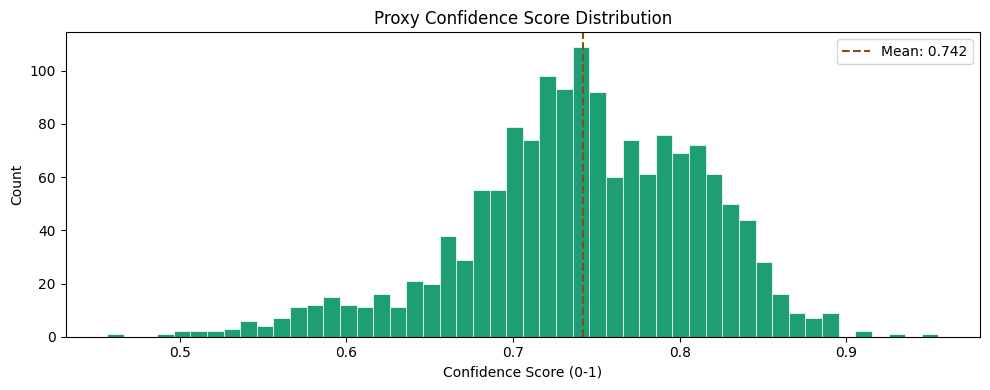

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_score_distribution.png
Score stats — mean: 0.742, std: 0.071, min: 0.457, max: 0.955


In [12]:
# VISUALIZATION 1: Confidence Score Distribution
plt.figure(figsize=(10, 4))
plt.hist(y_scores, bins=50, color='#1D9E75', edgecolor='white', linewidth=0.5)
plt.title('Proxy Confidence Score Distribution')
plt.xlabel('Confidence Score (0-1)')
plt.ylabel('Count')
plt.axvline(y_scores.mean(), color='#854F0B', linestyle='--', label=f'Mean: {y_scores.mean():.3f}')
plt.legend()
plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_score_distribution.png')
plt.savefig(p, dpi=150)
plt.show()
print(f'Saved to {p}')
print(f'Score stats — mean: {y_scores.mean():.3f}, std: {y_scores.std():.3f}, min: {y_scores.min():.3f}, max: {y_scores.max():.3f}')

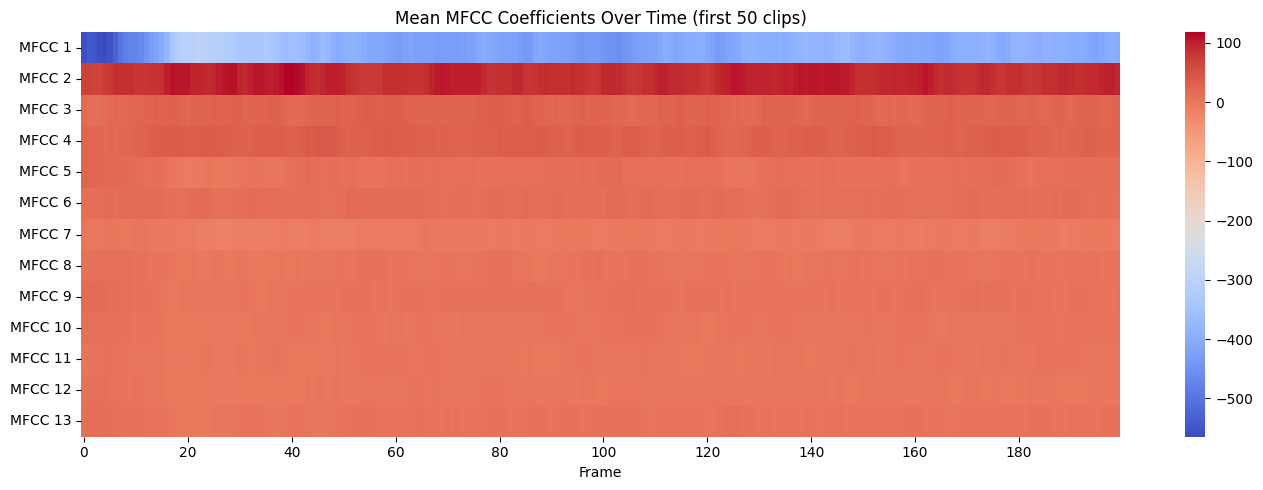

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_mfcc_heatmap.png


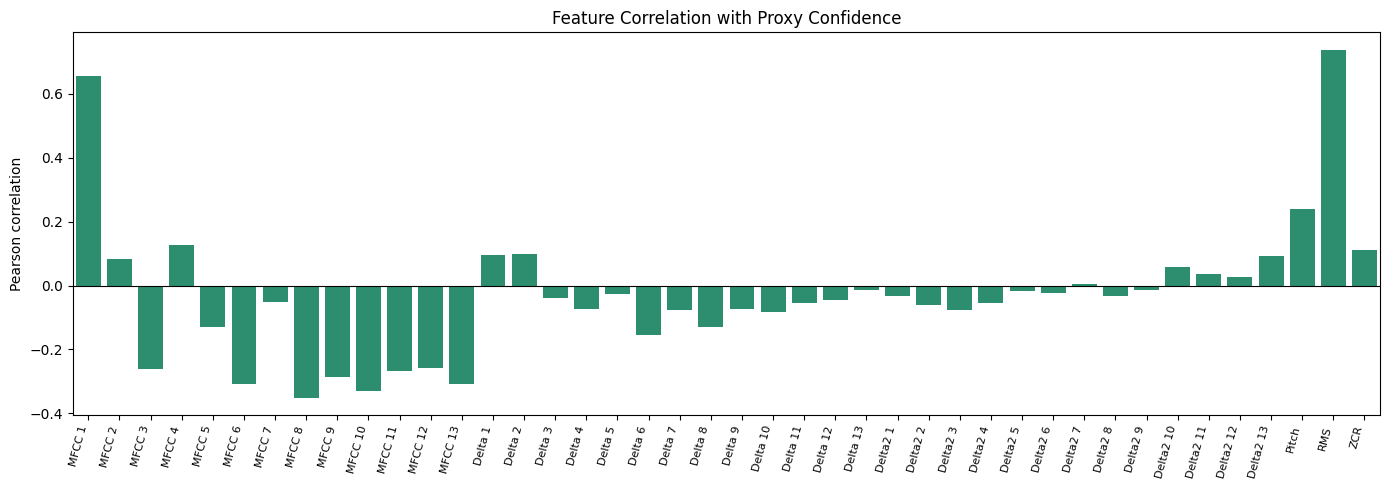

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_feature_confidence_correlations.png


In [13]:
# VISUALIZATION 2: Mean MFCC heatmap (first 50 clips, first 13 features)
sample_mfcc = X[:50, :, :13].mean(axis=0).T  # (13, 200)
plt.figure(figsize=(14, 5))
sns.heatmap(sample_mfcc, cmap='coolwarm', xticklabels=20, yticklabels=[f'MFCC {i+1}' for i in range(13)])
plt.title('Mean MFCC Coefficients Over Time (first 50 clips)')
plt.xlabel('Frame')
plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_mfcc_heatmap.png')
plt.savefig(p, dpi=150)
plt.show()
print(f'Saved to {p}')

# VISUALIZATION 3B: Feature-to-confidence correlations
feature_names = [f'MFCC {i+1}' for i in range(13)] + [f'Delta {i+1}' for i in range(13)] + [f'Delta2 {i+1}' for i in range(13)] + ['Pitch', 'RMS', 'ZCR']
feature_means = X.mean(axis=1)  # average each feature over time per clip
corrs = [np.corrcoef(feature_means[:, i], y_scores)[0, 1] for i in range(feature_means.shape[1])]
corrs = np.nan_to_num(corrs)

plt.figure(figsize=(14, 5))
sns.barplot(x=feature_names, y=corrs, color='#1D9E75')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Proxy Confidence')
plt.ylabel('Pearson correlation')
plt.xticks(rotation=75, ha='right', fontsize=8)
plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_feature_confidence_correlations.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {p}')

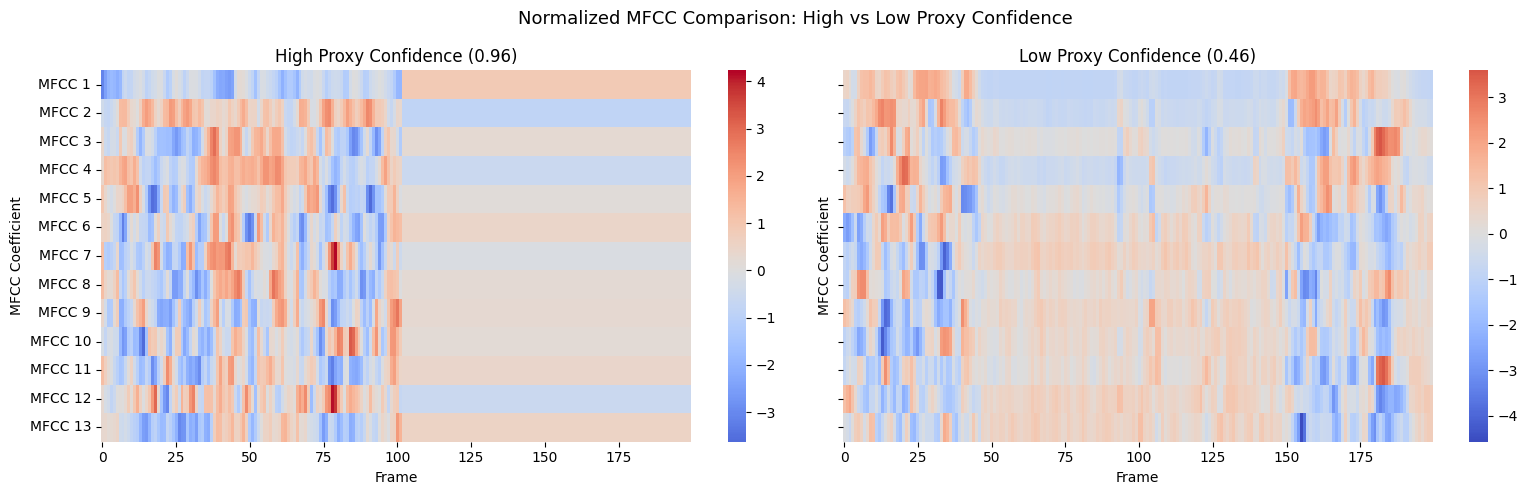

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_high_low_normalized_mfcc_heatmap.png


In [15]:
# VISUALIZATION 2B: Normalized MFCC heatmaps for high vs low confidence clips
high_idx = int(np.argmax(y_scores))
low_idx = int(np.argmin(y_scores))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle('Normalized MFCC Comparison: High vs Low Proxy Confidence', fontsize=13)

for ax, idx, title in [
    (axes[0], high_idx, f'High Proxy Confidence ({y_scores[high_idx]:.2f})'),
    (axes[1], low_idx, f'Low Proxy Confidence ({y_scores[low_idx]:.2f})')
]:
    mfcc = X[idx, :, :13].T
    mfcc_norm = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (
        mfcc.std(axis=1, keepdims=True) + 1e-8
    )

    sns.heatmap(
        mfcc_norm,
        cmap='coolwarm',
        center=0,
        xticklabels=25,
        yticklabels=[f'MFCC {i+1}' for i in range(13)],
        ax=ax,
        cbar=True
    )
    ax.set_title(title)
    ax.set_xlabel('Frame')
    ax.set_ylabel('MFCC Coefficient')

plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_high_low_normalized_mfcc_heatmap.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {p}')


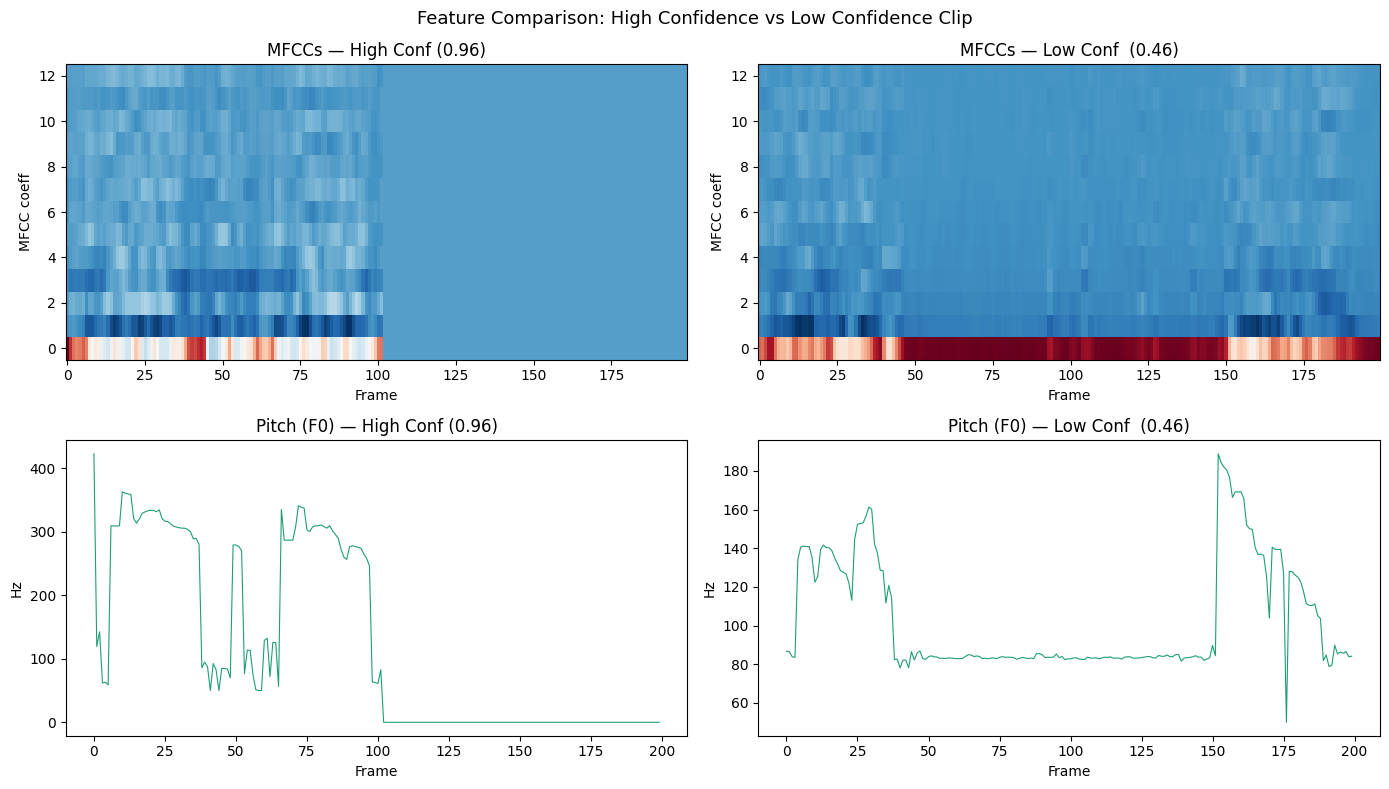

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_feature_comparison.png


In [16]:
# VISUALIZATION 3: Single clip feature breakdown (confident vs hesitant example)
high_idx = int(np.argmax(y_scores))
low_idx  = int(np.argmin(y_scores))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Feature Comparison: High Confidence vs Low Confidence Clip', fontsize=13)

for col, (idx, label) in enumerate([(high_idx, f'High Conf ({y_scores[high_idx]:.2f})'),
                                      (low_idx,  f'Low Conf  ({y_scores[low_idx]:.2f})')]):
    # MFCCs
    axes[0, col].imshow(X[idx, :, :13].T, aspect='auto', origin='lower', cmap='RdBu')
    axes[0, col].set_title(f'MFCCs — {label}')
    axes[0, col].set_xlabel('Frame'); axes[0, col].set_ylabel('MFCC coeff')

    # Pitch over time
    axes[1, col].plot(X[idx, :, 39], color='#1D9E75', linewidth=0.8)
    axes[1, col].set_title(f'Pitch (F0) — {label}')
    axes[1, col].set_xlabel('Frame'); axes[1, col].set_ylabel('Hz')

plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_feature_comparison.png')
plt.savefig(p, dpi=150)
plt.show()
print(f'Saved to {p}')

## 5. Preprocess: Normalise and Split

Confidence-bin counts before split:
  Low (<0.60): 73
  Medium (0.60-0.75): 755
  High (>=0.75): 691
Scaler saved to /content/drive/MyDrive/PersonaPath/lstm_features


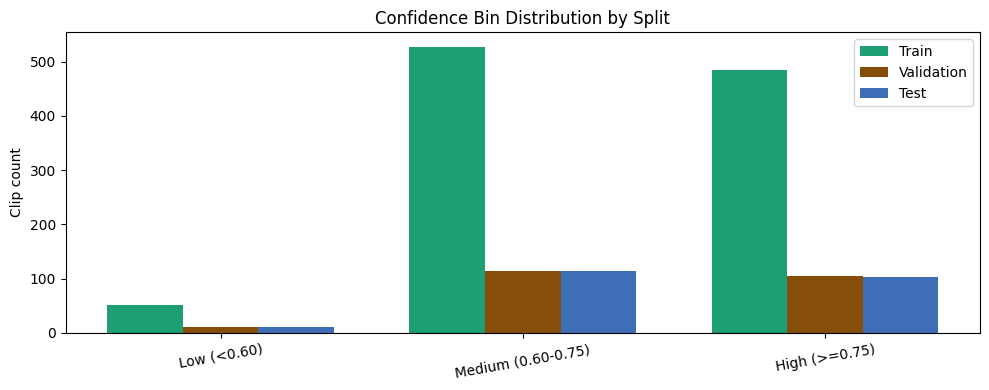

Saved split distribution to /content/drive/MyDrive/PersonaPath/visualizations/lstm_split_confidence_bins.png
Training bin weights:
  Low (<0.60): count=51, weight=6.948
  Medium (0.60-0.75): count=528, weight=0.671
  High (>=0.75): count=484, weight=0.732
Train:      (1063, 200, 42)  labels: (1063,)
Validation: (228, 200, 42)  labels: (228,)
Test:       (228, 200, 42)  labels: (228,)


In [17]:
# Split first, then normalise using training-set statistics only.
# This avoids leaking validation/test distribution information into the scaler.
N, T, F = X.shape

# Confidence-bin-aware split + sample weights.
# This avoids a misleading train/val/test split where the rare low-confidence
# clips accidentally vanish from one split.
CONFIDENCE_BIN_EDGES = [0.60, 0.75]
CONFIDENCE_BIN_LABELS = ['Low (<0.60)', 'Medium (0.60-0.75)', 'High (>=0.75)']
y_bins = np.digitize(y_scores, bins=CONFIDENCE_BIN_EDGES)

bin_counts = np.bincount(y_bins, minlength=len(CONFIDENCE_BIN_LABELS))
can_stratify = np.count_nonzero(bin_counts) > 1 and np.all(bin_counts[bin_counts > 0] >= 2)
print('Confidence-bin counts before split:')
for label, count in zip(CONFIDENCE_BIN_LABELS, bin_counts):
    print(f'  {label}: {count}')

# Train / val / test split (70 / 15 / 15)
if can_stratify:
    X_tr, X_temp, y_tr, y_temp, bins_tr, bins_temp = train_test_split(
        X, y_scores, y_bins,
        test_size=0.30,
        random_state=42,
        stratify=y_bins
    )
    X_val, X_te, y_val, y_te, bins_val, bins_te = train_test_split(
        X_temp, y_temp, bins_temp,
        test_size=0.50,
        random_state=42,
        stratify=bins_temp
    )
else:
    print('Not enough samples per bin for stratified split; falling back to random split.')
    X_tr, X_temp, y_tr, y_temp = train_test_split(X, y_scores, test_size=0.30, random_state=42)
    X_val, X_te, y_val, y_te = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
    bins_tr = np.digitize(y_tr, bins=CONFIDENCE_BIN_EDGES)
    bins_val = np.digitize(y_val, bins=CONFIDENCE_BIN_EDGES)
    bins_te = np.digitize(y_te, bins=CONFIDENCE_BIN_EDGES)

# Fit scaler on train only, then transform validation/test with the same scaler.
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr.reshape(-1, F)).reshape(X_tr.shape).astype(np.float32)
X_val = scaler.transform(X_val.reshape(-1, F)).reshape(X_val.shape).astype(np.float32)
X_te = scaler.transform(X_te.reshape(-1, F)).reshape(X_te.shape).astype(np.float32)

# Save scaler params to Drive (needed at inference time)
np.save(os.path.join(FEATURE_DIR, 'scaler_mean.npy'), scaler.mean_)
np.save(os.path.join(FEATURE_DIR, 'scaler_scale.npy'), scaler.scale_)
print(f'Scaler saved to {FEATURE_DIR}')

# Give rare confidence bins more influence during training so the model is less
# incentivized to collapse to the global mean.
train_bin_counts = np.bincount(bins_tr, minlength=len(CONFIDENCE_BIN_LABELS))
bin_weights = np.zeros_like(train_bin_counts, dtype=np.float32)
nonzero_bins = train_bin_counts > 0
bin_weights[nonzero_bins] = len(bins_tr) / (np.count_nonzero(nonzero_bins) * train_bin_counts[nonzero_bins])
sample_weights = bin_weights[bins_tr].astype(np.float32)

SPLIT_DISTRIBUTION_PATH = os.path.join(VISUALIZATION_DIR, 'lstm_split_confidence_bins.png')
split_counts = np.vstack([
    np.bincount(bins_tr, minlength=len(CONFIDENCE_BIN_LABELS)),
    np.bincount(bins_val, minlength=len(CONFIDENCE_BIN_LABELS)),
    np.bincount(bins_te, minlength=len(CONFIDENCE_BIN_LABELS)),
])
x = np.arange(len(CONFIDENCE_BIN_LABELS))
width = 0.25
plt.figure(figsize=(10, 4))
plt.bar(x - width, split_counts[0], width, label='Train', color='#1D9E75')
plt.bar(x, split_counts[1], width, label='Validation', color='#854F0B')
plt.bar(x + width, split_counts[2], width, label='Test', color='#3E6FB6')
plt.xticks(x, CONFIDENCE_BIN_LABELS, rotation=10)
plt.ylabel('Clip count')
plt.title('Confidence Bin Distribution by Split')
plt.legend()
plt.tight_layout()
plt.savefig(SPLIT_DISTRIBUTION_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved split distribution to {SPLIT_DISTRIBUTION_PATH}')

print('Training bin weights:')
for label, count, weight in zip(CONFIDENCE_BIN_LABELS, train_bin_counts, bin_weights):
    print(f'  {label}: count={count}, weight={weight:.3f}')

print(f'Train:      {X_tr.shape}  labels: {y_tr.shape}')
print(f'Validation: {X_val.shape}  labels: {y_val.shape}')
print(f'Test:       {X_te.shape}  labels: {y_te.shape}')

## 6. Build the LSTM Model
Input: **(200 frames, 42 features)** — no image conversion, direct sequence modelling.

```
Input (200, 42)
  └─ LSTM(128, return_sequences=True) + Dropout(0.3)
       └─ LSTM(64, return_sequences=False) + Dropout(0.3)
            └─ Dense(32, relu)
                 └─ Dense(1, sigmoid)  →  confidence score 0-1
```

In [18]:
def build_lstm_model(input_shape=(MAX_FRAMES, N_FEATURES)):
    inputs = tf.keras.Input(shape=input_shape, name='audio_features')

    x = tf.keras.layers.LSTM(128, return_sequences=True, name='lstm_1')(inputs)
    x = tf.keras.layers.Dropout(0.3, name='drop_1')(x)

    x = tf.keras.layers.LSTM(64, return_sequences=False, name='lstm_2')(x)
    x = tf.keras.layers.Dropout(0.3, name='drop_2')(x)

    x = tf.keras.layers.Dense(32, activation='relu', name='dense_1')(x)

    output = tf.keras.layers.Dense(1, activation='sigmoid', name='confidence_score')(x)

    model = tf.keras.Model(inputs, output, name='PersonaPath_LSTM_Confidence')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_lstm_model()
model.summary()

MODEL_SUMMARY_PATH = os.path.join(VISUALIZATION_DIR, 'lstm_model_summary.txt')
with open(MODEL_SUMMARY_PATH, 'w') as f:
    model.summary(print_fn=lambda line: f.write(line + '\n'))
print(f'Model summary saved to {MODEL_SUMMARY_PATH}')

Model: "PersonaPath_LSTM_Confidence"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio_features (InputLayer)     │ (None, 200, 42)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 200, 128)       │        87,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ confidence_score (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,073 (543.25 KB)

 Trainable params: 139,073 (543.25 KB)

 Non-trainable params: 0 (0.00 B)

Model summary saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_model_summary.txt


## 7. Train with Early Stopping and Drive Checkpointing

In [19]:
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'lstm_confidence_best.keras')
TRAINING_LOG_PATH = os.path.join(VISUALIZATION_DIR, 'lstm_training_log.csv')
BACKUP_DIR = os.path.join(CHECKPOINT_DIR, 'lstm_training_backup')

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=5, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_mae', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.CSVLogger(TRAINING_LOG_PATH, append=False),
    tf.keras.callbacks.BackupAndRestore(BACKUP_DIR),
]

print('Starting LSTM training...')
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    sample_weight=sample_weights,
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
print('Training complete.')

Starting LSTM training...
Epoch 1/50
15/17 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0321 - mae: 0.1862
Epoch 1: val_mae improved from None to 0.07291, saving model to /content/drive/MyDrive/PersonaPath/checkpoints/lstm_confidence_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PersonaPath/checkpoints/lstm_confidence_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0204 - mae: 0.1352 - val_loss: 0.0083 - val_mae: 0.0729 - learning_rate: 0.0010
Epoch 2/50
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0076 - mae: 0.0689
Epoch 2: val_mae improved from 0.07291 to 0.06068, saving model to /content/drive/MyDrive/PersonaPath/checkpoints/lstm_confidence_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PersonaPath/checkpoints/lstm_confidence_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0073 - mae: 0.0669 - val_loss: 0.0060 - val_mae: 0.0607 - learning_rate: 0.0010
Epoch 3/50
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - los

## 8. Resume Training from Checkpoint (Run This If Session Expired)

In [ ]:
# ── Only run this cell if you need to resume after a Colab disconnect ──

print('Rebuilding model architecture...')
model = build_lstm_model()

print(f'Loading weights from {CHECKPOINT_PATH}...')
model.load_weights(CHECKPOINT_PATH)
print('Weights loaded. Resuming training...')

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    sample_weight=sample_weights,
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Rebuilding model architecture...
Loading weights from /content/drive/MyDrive/PersonaPath/checkpoints/lstm_confidence_best.keras...
Weights loaded. Resuming training...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0018 - mae: 0.0326
Epoch 1: val_mae did not improve from 0.02792
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0017 - mae: 0.0315 - val_loss: 0.0015 - val_mae: 0.0310 - learning_rate: 0.0010
Epoch 2/50
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0014 - mae: 0.0288
Epoch 2: val_mae did not improve from 0.02792
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0014 - mae: 0.0291 - val_loss: 0.0017 - val_mae: 0.0319 - learning_rate: 0.0010
Epoch 3/50
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016 - mae: 0.0307
Epoch 3: val_mae did not improve from 0.02792

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0016 - mae: 0.0309 - val_loss: 0.0015 - val_mae: 0.0301 - learning_rate: 0.0010
Epoch 4/50
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0013 - mae: 0.0268
Epoch 4: val_mae did not improve from 0.02792
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step 

## 9. Training Curves

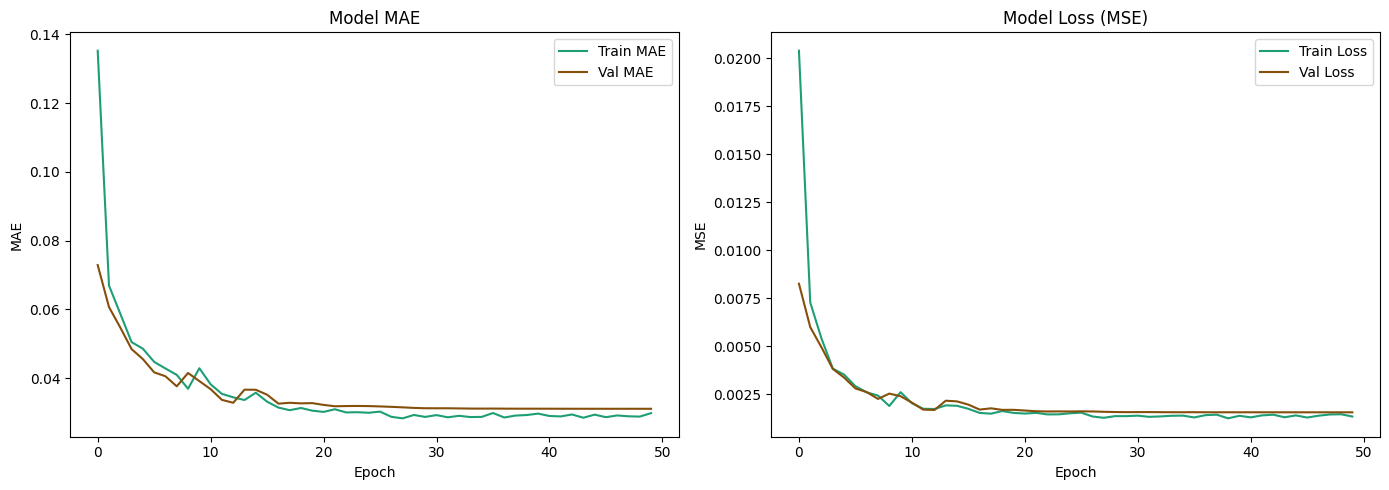

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_training_curves.png


In [20]:
# VISUALIZATION 4: Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['mae'],     label='Train MAE', color='#1D9E75')
axes[0].plot(history.history['val_mae'], label='Val MAE',   color='#854F0B')
axes[0].set_title('Model MAE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss', color='#1D9E75')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#854F0B')
axes[1].set_title('Model Loss (MSE)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_training_curves.png')
plt.savefig(p, dpi=150)
plt.show()
print(f'Saved to {p}')

In [21]:
model = build_lstm_model()
model.load_weights(CHECKPOINT_PATH)
print("Loaded best checkpoint for final evaluation.")


Loaded best checkpoint for final evaluation.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [22]:
test_loss, test_mae = model.evaluate(X_te, y_te, verbose=0)
y_pred = model.predict(X_te, verbose=0).flatten()


## 10. Evaluate on Test Set

In [23]:
test_loss, test_mae = model.evaluate(X_te, y_te, verbose=0)
y_pred = model.predict(X_te, verbose=0).flatten()

baseline_pred = np.full_like(y_te, fill_value=float(np.mean(y_tr)))
baseline_mae = mean_absolute_error(y_te, baseline_pred)
model_mae = mean_absolute_error(y_te, y_pred)
improvement_points = (baseline_mae - model_mae) * 100
prediction_std = float(np.std(y_pred))
target_std = float(np.std(y_te))

print(f'Test MSE : {test_loss:.4f}')
print(f'Test MAE : {test_mae:.4f}')
print(f'Mean-baseline MAE: {baseline_mae:.4f}')
print(f'LSTM improvement over baseline: {improvement_points:.2f} confidence points')
print(f'Prediction std: {prediction_std:.4f}')
print(f'Target std    : {target_std:.4f}')
print(f'\nIn human terms: on average, predictions are off by {test_mae*100:.1f} confidence points (0-100 scale)')

bin_metrics = []
print('\nBin-wise test MAE:')
test_bins = np.digitize(y_te, bins=CONFIDENCE_BIN_EDGES)
for bin_id, label in enumerate(CONFIDENCE_BIN_LABELS):
    mask = test_bins == bin_id
    if np.sum(mask) == 0:
        print(f'  {label}: no test samples')
        continue
    mae_bin = mean_absolute_error(y_te[mask], y_pred[mask])
    baseline_mae_bin = mean_absolute_error(y_te[mask], baseline_pred[mask])
    bin_metrics.append({
        'bin': label,
        'samples': int(np.sum(mask)),
        'model_mae': float(mae_bin),
        'baseline_mae': float(baseline_mae_bin),
        'improvement_points_0_100': float((baseline_mae_bin - mae_bin) * 100),
    })
    print(f'  {label}: model MAE={mae_bin:.4f}, baseline MAE={baseline_mae_bin:.4f}, samples={np.sum(mask)}')

METRICS_PATH = os.path.join(VISUALIZATION_DIR, 'lstm_test_metrics.json')
PREDICTIONS_PATH = os.path.join(VISUALIZATION_DIR, 'lstm_test_predictions.csv')
with open(METRICS_PATH, 'w') as f:
    json.dump({
        'test_mse': float(test_loss),
        'test_mae': float(test_mae),
        'mae_points_0_100': float(test_mae * 100),
        'mean_baseline_mae': float(baseline_mae),
        'baseline_improvement_points_0_100': float(improvement_points),
        'prediction_std': prediction_std,
        'target_std': target_std,
        'bin_metrics': bin_metrics,
    }, f, indent=2)
np.savetxt(PREDICTIONS_PATH, np.column_stack([y_te, y_pred, baseline_pred, y_pred - y_te]), delimiter=',', header='true_confidence,predicted_confidence,mean_baseline_prediction,residual', comments='')
print(f'Saved metrics to {METRICS_PATH}')
print(f'Saved predictions to {PREDICTIONS_PATH}')

Test MSE : 0.0022
Test MAE : 0.0344
Mean-baseline MAE: 0.0569
LSTM improvement over baseline: 2.25 confidence points
Prediction std: 0.0585
Target std    : 0.0740

In human terms: on average, predictions are off by 3.4 confidence points (0-100 scale)

Bin-wise test MAE:
  Low (<0.60): model MAE=0.0634, baseline MAE=0.1816, samples=11
  Medium (0.60-0.75): model MAE=0.0308, baseline MAE=0.0435, samples=114
  High (>=0.75): model MAE=0.0353, baseline MAE=0.0584, samples=103
Saved metrics to /content/drive/MyDrive/PersonaPath/visualizations/lstm_test_metrics.json
Saved predictions to /content/drive/MyDrive/PersonaPath/visualizations/lstm_test_predictions.csv


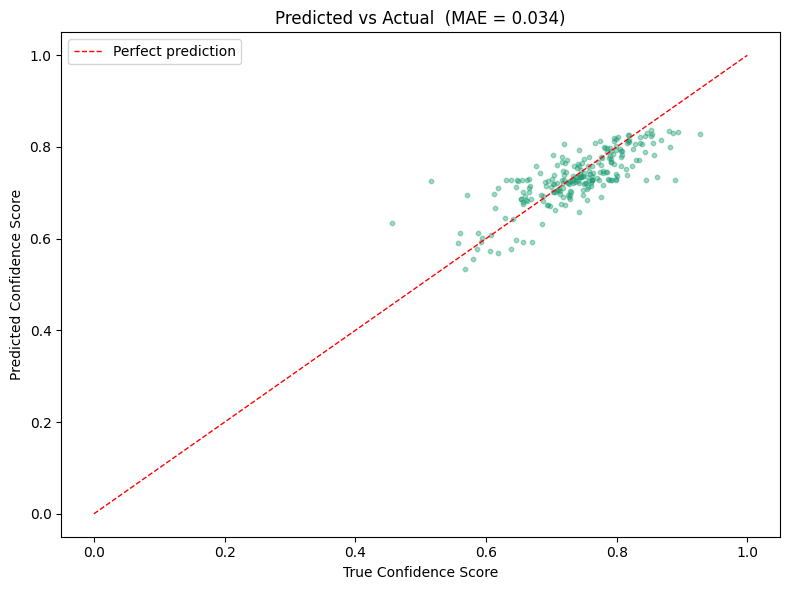

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_pred_vs_actual.png


In [24]:
# VISUALIZATION 5: Predicted vs Actual Scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_te, y_pred, alpha=0.4, s=10, color='#1D9E75')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('True Confidence Score')
plt.ylabel('Predicted Confidence Score')
plt.title(f'Predicted vs Actual  (MAE = {test_mae:.3f})')
plt.legend()
plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_pred_vs_actual.png')
plt.savefig(p, dpi=150)
plt.show()
print(f'Saved to {p}')

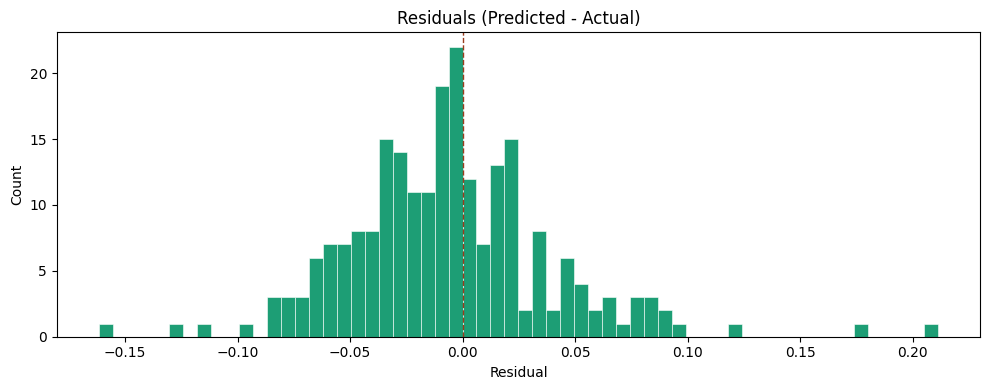

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_residuals.png


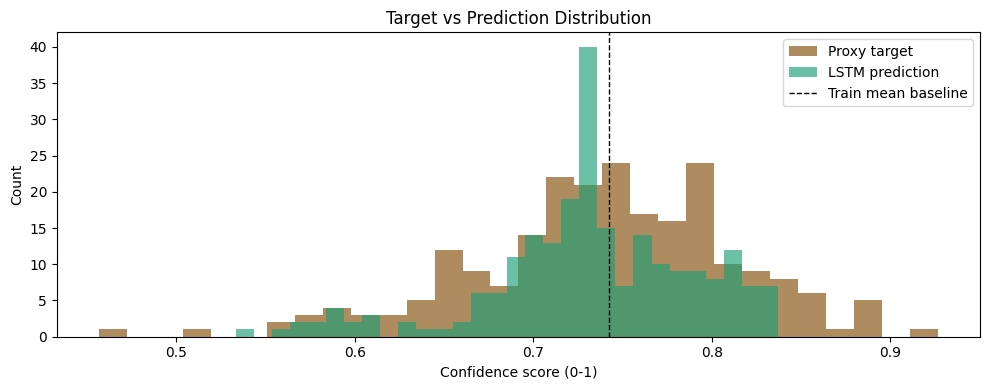

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_target_vs_prediction_distribution.png


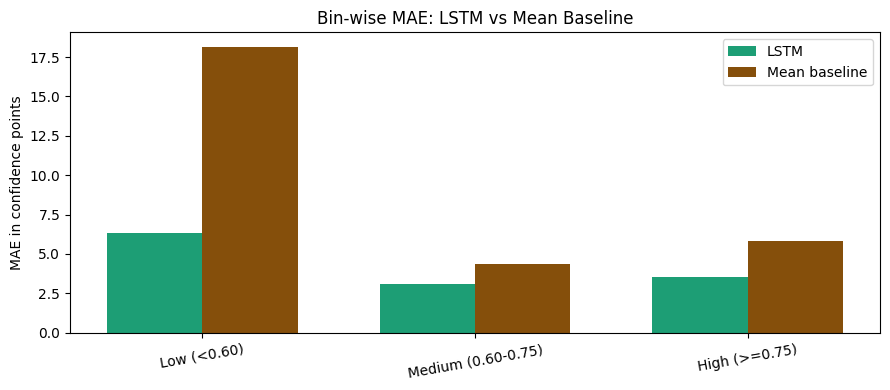

Saved to /content/drive/MyDrive/PersonaPath/visualizations/lstm_binwise_mae_vs_baseline.png


In [25]:
# VISUALIZATION 6: Residual Distribution
residuals = y_pred - y_te
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=60, color='#1D9E75', edgecolor='white', linewidth=0.4)
plt.axvline(0, color='#993C1D', linestyle='--', linewidth=1)
plt.title('Residuals (Predicted - Actual)')
plt.xlabel('Residual'); plt.ylabel('Count')
plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_residuals.png')
plt.savefig(p, dpi=150)
plt.show()
print(f'Saved to {p}')

# VISUALIZATION 6B: Target vs prediction distribution collapse check
plt.figure(figsize=(10, 4))
plt.hist(y_te, bins=30, alpha=0.65, label='Proxy target', color='#854F0B')
plt.hist(y_pred, bins=30, alpha=0.65, label='LSTM prediction', color='#1D9E75')
plt.axvline(np.mean(y_tr), color='black', linestyle='--', linewidth=1, label='Train mean baseline')
plt.title('Target vs Prediction Distribution')
plt.xlabel('Confidence score (0-1)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
p = os.path.join(VISUALIZATION_DIR, 'lstm_target_vs_prediction_distribution.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {p}')

# VISUALIZATION 6C: Bin-wise MAE vs mean baseline
if bin_metrics:
    labels = [m['bin'] for m in bin_metrics]
    model_scores = [m['model_mae'] * 100 for m in bin_metrics]
    baseline_scores = [m['baseline_mae'] * 100 for m in bin_metrics]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(9, 4))
    plt.bar(x - width / 2, model_scores, width, label='LSTM', color='#1D9E75')
    plt.bar(x + width / 2, baseline_scores, width, label='Mean baseline', color='#854F0B')
    plt.xticks(x, labels, rotation=10)
    plt.ylabel('MAE in confidence points')
    plt.title('Bin-wise MAE: LSTM vs Mean Baseline')
    plt.legend()
    plt.tight_layout()
    p = os.path.join(VISUALIZATION_DIR, 'lstm_binwise_mae_vs_baseline.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {p}')

## 11. Inference Helper (Used by Person B in app.py)

In [26]:
# Load saved scaler params
scaler_mean  = np.load(os.path.join(FEATURE_DIR, 'scaler_mean.npy'))
scaler_scale = np.load(os.path.join(FEATURE_DIR, 'scaler_scale.npy'))

def predict_confidence(audio_path, model, scaler_mean, scaler_scale):
    """
    Given a path to any audio/video file, returns a confidence score 0-100.
    This is the function Person B calls from app.py.
    """
    feat    = extract_features(audio_path)                           # (200, 42)
    feat_n  = ((feat - scaler_mean) / scaler_scale).astype(np.float32)
    feat_n  = np.expand_dims(feat_n, axis=0)                        # (1, 200, 42)
    score   = float(model.predict(feat_n, verbose=0)[0][0])
    return round(score * 100, 1)  # scale to 0-100

# Quick sanity check on a test clip
test_clip = audio_files[0]
demo_score = predict_confidence(test_clip, model, scaler_mean, scaler_scale)
print(f'Demo inference on: {os.path.basename(test_clip)}')
print(f'Predicted confidence: {demo_score}/100')

Demo inference on: 163-122947-0061.flac
Predicted confidence: 55.2/100


## 12. Save Final Model and Push to Hugging Face

In [28]:
FINAL_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'lstm_confidence_final.keras')
model.save(FINAL_MODEL_PATH)
print(f'Final model saved to {FINAL_MODEL_PATH}')
print(f'Best checkpoint remains saved at {CHECKPOINT_PATH}')
print(f'Scaler params saved at {FEATURE_DIR}')
print(f'Visualisations and logs saved at {VISUALIZATION_DIR}')

Final model saved to /content/drive/MyDrive/PersonaPath/checkpoints/lstm_confidence_final.keras
Best checkpoint remains saved at /content/drive/MyDrive/PersonaPath/checkpoints/lstm_confidence_best.keras
Scaler params saved at /content/drive/MyDrive/PersonaPath/lstm_features
Visualisations and logs saved at /content/drive/MyDrive/PersonaPath/visualizations


In [29]:
from huggingface_hub import HfApi, notebook_login

# Run this once per Colab session if you are not already logged in.
notebook_login()

REPO_ID = 'iamnotpalak/personapath-lstm-vocal-confidence-mfcc'  # update this before running
if REPO_ID.startswith('YOUR_HF_USERNAME/'):
    raise ValueError('Set REPO_ID to your real Hugging Face repo, e.g. palakbhatt1/personapath-lstm-confidence')

api = HfApi()
api.create_repo(repo_id=REPO_ID, exist_ok=True)

files_to_upload = [
    (FINAL_MODEL_PATH, 'lstm_confidence_final.keras'),
    (CHECKPOINT_PATH, 'lstm_confidence_best.keras'),
    (os.path.join(FEATURE_DIR, 'scaler_mean.npy'), 'scaler_mean.npy'),
    (os.path.join(FEATURE_DIR, 'scaler_scale.npy'), 'scaler_scale.npy'),
    (METRICS_PATH, 'artifacts/lstm_test_metrics.json'),
    (PREDICTIONS_PATH, 'artifacts/lstm_test_predictions.csv'),
    (TRAINING_LOG_PATH, 'artifacts/lstm_training_log.csv'),
    (MODEL_SUMMARY_PATH, 'artifacts/lstm_model_summary.txt'),
]

for fname in [
    'lstm_score_distribution.png',
    'lstm_split_confidence_bins.png',
    'lstm_mfcc_heatmap.png',
    'lstm_feature_confidence_correlations.png',
    'lstm_feature_comparison.png',
    'lstm_training_curves.png',
    'lstm_pred_vs_actual.png',
    'lstm_residuals.png',
    'lstm_target_vs_prediction_distribution.png',
    'lstm_binwise_mae_vs_baseline.png',
]:
    files_to_upload.append((os.path.join(VISUALIZATION_DIR, fname), f'artifacts/{fname}'))

for local_path, repo_path in files_to_upload:
    if os.path.exists(local_path):
        api.upload_file(path_or_fileobj=local_path, path_in_repo=repo_path, repo_id=REPO_ID)
        print(f'Uploaded {repo_path}')
    else:
        print(f'Skipped missing file: {local_path}')

print(f'Model, scaler, metrics, logs, and visualisations pushed to https://huggingface.co/{REPO_ID}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...tm_confidence_final.keras: 100%|#########9|  593kB /  594kB            

Uploaded lstm_confidence_final.keras


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Uploaded scaler_scale.npy
Uploaded artifacts/lstm_test_metrics.json
Uploaded artifacts/lstm_test_predictions.csv
Uploaded artifacts/lstm_training_log.csv
Uploaded artifacts/lstm_model_summary.txt
Uploaded artifacts/lstm_score_distribution.png
Uploaded artifacts/lstm_split_confidence_bins.png
Uploaded artifacts/lstm_mfcc_heatmap.png
Uploaded artifacts/lstm_feature_confidence_correlations.png


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...tm_feature_comparison.png: 100%|##########|  145kB /  145kB            

Uploaded artifacts/lstm_feature_comparison.png
Uploaded artifacts/lstm_training_curves.png
Uploaded artifacts/lstm_pred_vs_actual.png
Uploaded artifacts/lstm_residuals.png
Uploaded artifacts/lstm_target_vs_prediction_distribution.png
Uploaded artifacts/lstm_binwise_mae_vs_baseline.png
Model, scaler, metrics, logs, and visualisations pushed to https://huggingface.co/iamnotpalak/personapath-lstm-vocal-confidence-mfcc


## Summary

| Step | Detail |
|------|--------|
| Dataset | Mini LibriSpeech (~1.5 GB, ~1,700 clips) |
| Features | 42 per frame: 13 MFCC + 13 delta + 13 delta-delta + pitch + RMS + ZCR |
| Sequence length | 200 frames (padded/truncated) |
| Architecture | LSTM(128) → LSTM(64) → Dense(32) → Dense(1, sigmoid) |
| Loss | MSE  |  Optimiser | Adam  |  Metric | MAE |
| Labels | Proxy confidence from speech density, RMS energy, pitch variation |
| Inference | `predict_confidence(audio_path)` → score 0–100 |
| Saved to | Google Drive checkpoints + Hugging Face |

**No spectrograms used.** All features are direct numerical sequences fed natively into the LSTM.